In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from modules.finance.exploration import *

plt.rcParams.update({"font.size": 14})
pd.set_option("display.max_columns", None)

In [2]:
# Configuration
DATA_DIR = "./data/"
OUTPUT_DIR = "./data/fm_prelim/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Files
FINANCIAL_PANEL_FILE = DATA_DIR + "financial_returns_and_controls.parquet"
EPI_DATA_FILE = DATA_DIR + "epi_data_all_lownull.json"

# Parameters
ROLLING_WINDOW = 14
MAX_LAG = 10
IC = 'aic'
ALPHA = 0.05
CORRECTION_METHOD = 'fdr_bh'

print("✓ Configuration complete")

✓ Configuration complete


## Load Data

In [3]:
# Load data
df_returns = pd.read_parquet(FINANCIAL_PANEL_FILE)
df_epi = pd.read_json(EPI_DATA_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

df = df_returns.join(df_epi, how='left')
df[df_epi.columns] = df[df_epi.columns].fillna(0)

print(f"Data loaded: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Data loaded: (108, 115)
Date range: 2025-01-01 00:00:00 to 2025-05-30 00:00:00


In [4]:
# Find CCD variants
ccd_variants = find_index_variants(df.columns, 'ccd')
ASSET_COLS = ['r_btc', 'r_gold', 'r_spx']
ASSET_COLS = [c for c in ASSET_COLS if c in df.columns]

print(f"\nCCD variants found: {len(ccd_variants)}")
for i, var in enumerate(ccd_variants, 1):
    print(f"  {i}. {var}")
print(f"\nAssets: {ASSET_COLS}")


CCD variants found: 4
  1. ccd
  2. ccd_engweighted
  3. ccd_topicweighted
  4. ccd_engweighted_topicweighted

Assets: ['r_btc', 'r_gold', 'r_spx']


## Descriptive Statistics


Descriptive Statistics

CCD Variants


,count,mean,std,min,25%,50%,75%,max,skew,kurt,missing_pct,zero_pct
ccd,108.0,0.133902,0.107345,0.0,0.061972,0.109722,0.169932,0.499999,1.222648,1.403476,0.0,1.851852
ccd_engweighted,108.0,0.128723,0.105637,0.0,0.057389,0.103849,0.161518,0.500000,1.365762,1.751917,0.0,1.851852
ccd_engweighted_topicweighted,108.0,0.079312,0.063189,0.0,0.032026,0.071010,0.127871,0.264471,0.595176,-0.387755,0.0,10.185185
ccd_topicweighted,108.0,0.113910,0.084063,0.0,0.043507,0.113330,0.155273,0.348601,0.458966,-0.425604,0.0,8.333333



Correlation between variants:


,ccd,ccd_engweighted,ccd_topicweighted,ccd_engweighted_topicweighted
ccd,1.000000,0.978484,0.462228,-0.049094
ccd_engweighted,0.978484,1.000000,0.415081,-0.045699
ccd_topicweighted,0.462228,0.415081,1.000000,-0.023390
ccd_engweighted_topicweighted,-0.049094,-0.045699,-0.023390,1.000000


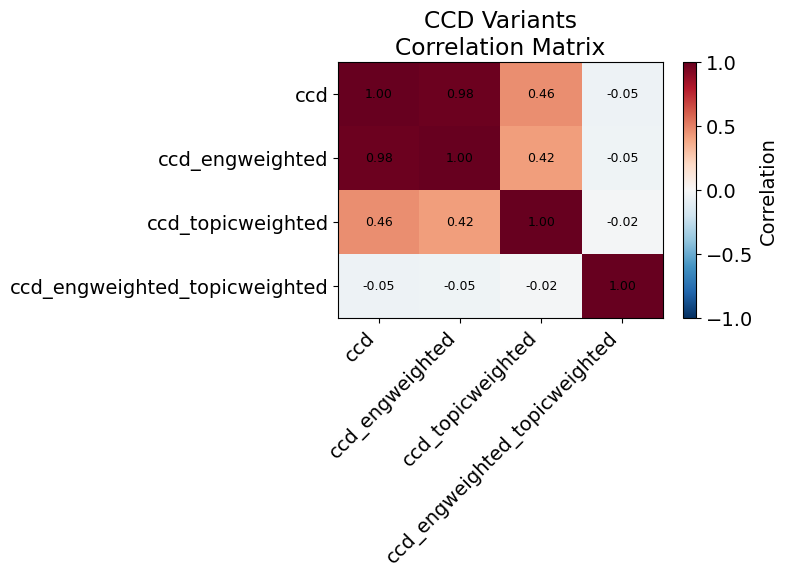

In [5]:
print("\n" + "="*70)
print("Descriptive Statistics")
print("="*70)
stats = compare_index_variants_descriptive(df, ccd_variants, 'CCD Variants')

## Time Series Visualization


Time Series Visualization


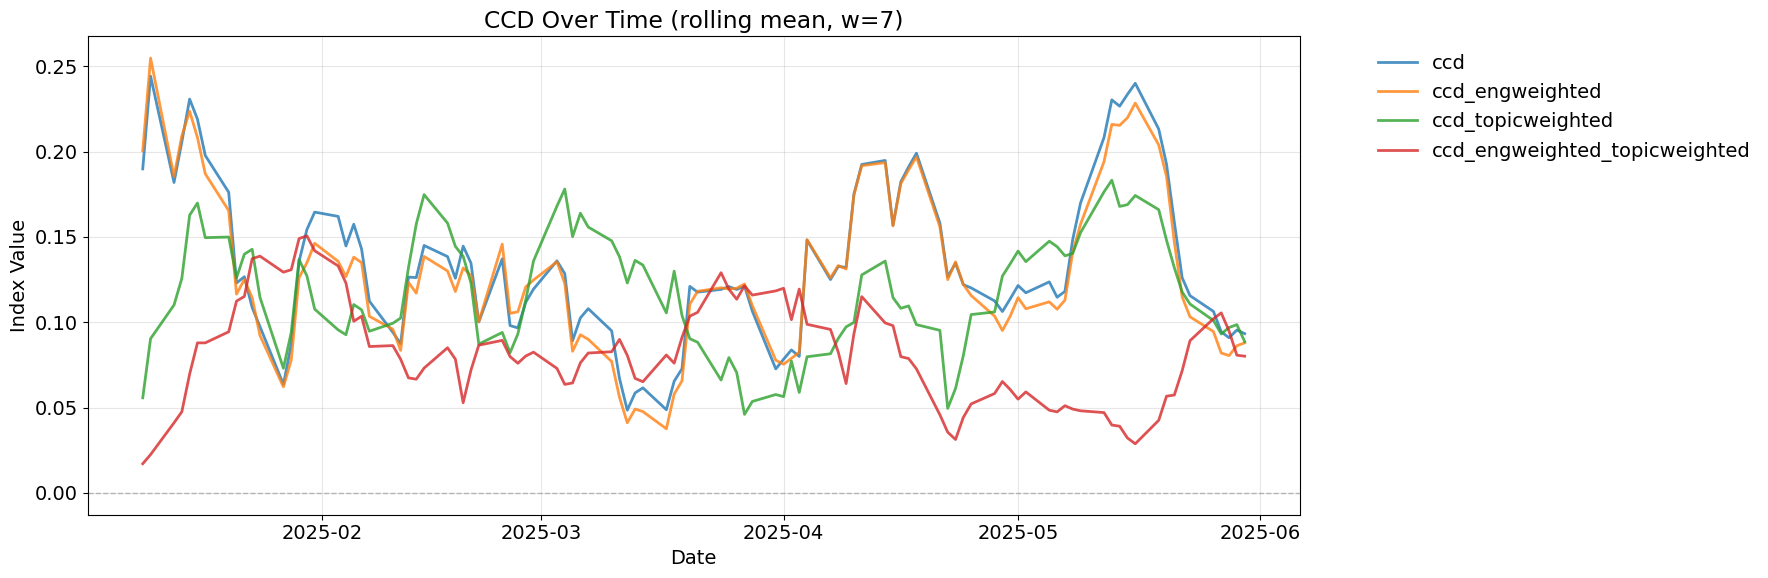

In [6]:
print("\n" + "="*70)
print("Time Series Visualization")
print("="*70)
compare_index_variants_timeseries(df, ccd_variants, 'CCD Over Time', rolling_window=7)

## Rolling Correlations with Assets


Rolling Correlations with Assets


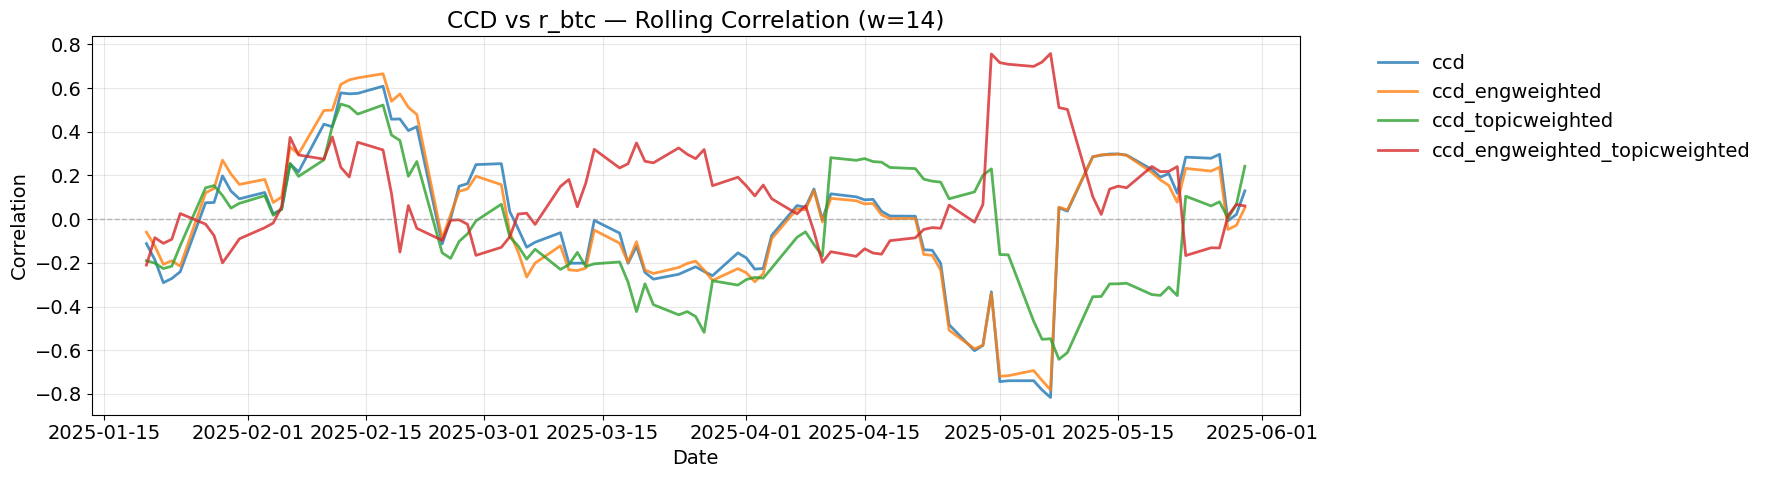

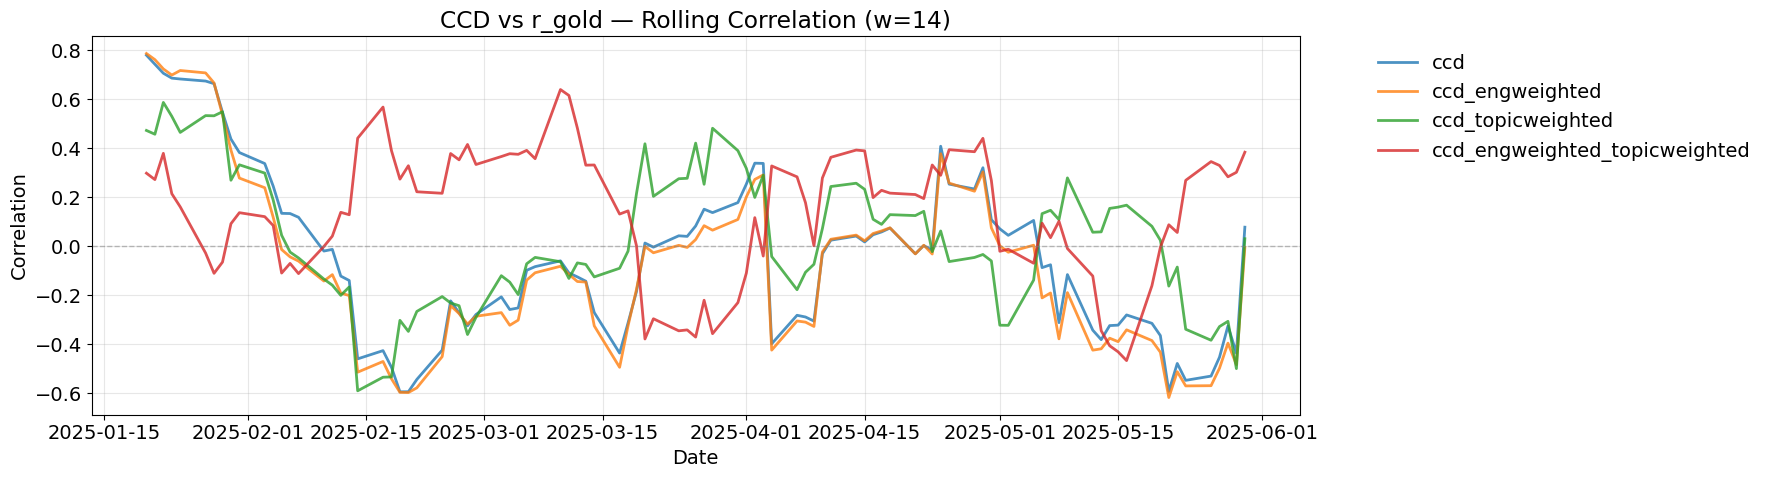

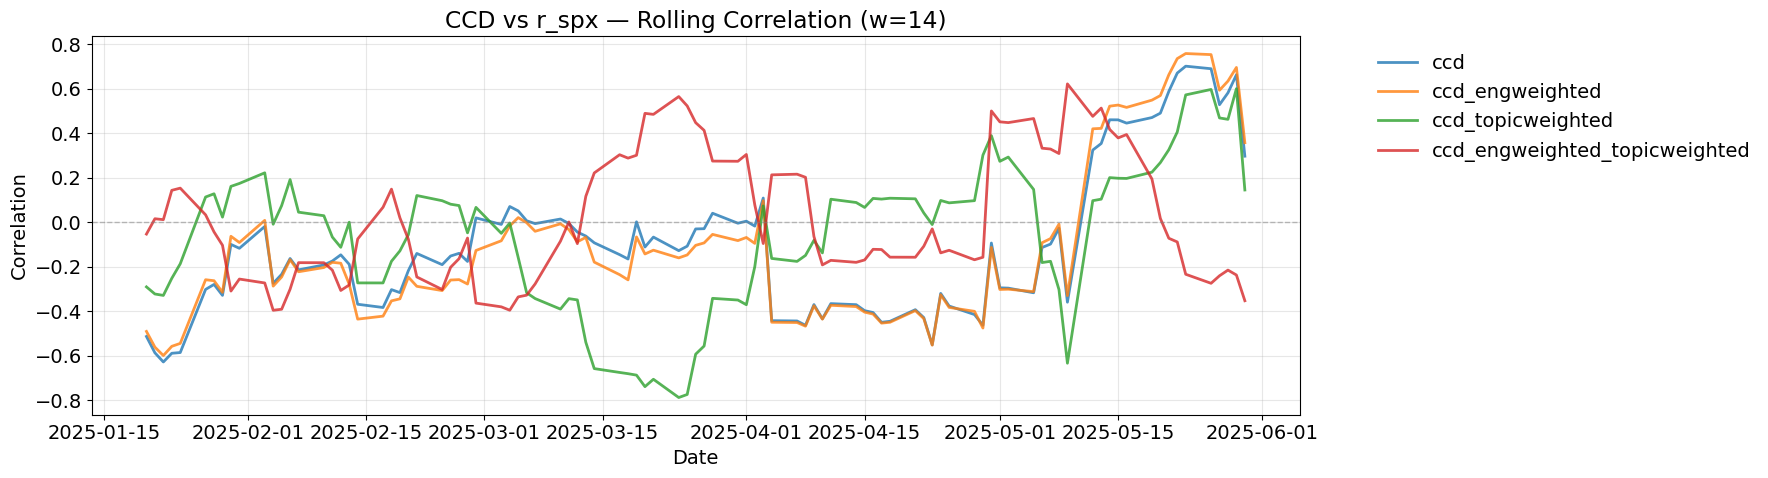

In [7]:
print("\n" + "="*70)
print("Rolling Correlations with Assets")
print("="*70)
compare_variants_vs_assets(df, ccd_variants, ASSET_COLS, 'CCD', rolling_window=ROLLING_WINDOW)

## Granger Causality Tests

Test if CCD variants Granger-cause asset returns using:
- AIC/BIC for optimal lag selection
- Benjamini-Hochberg FDR correction for multiple testing


Granger Causality Tests

GRANGER CAUSALITY TESTS: CCD Variants
Running 12 Granger causality tests...
  Index → Asset causality
  Max lag: 10, IC: AIC
  Multiple testing correction: fdr_bh

✓ Tests complete
  Significant relationships (corrected α=0.05): 0 of 12
  Uncorrected significant (α=0.05): 1

P-values (at optimal lag):


asset,r_btc,r_gold,r_spx
index,,,
ccd,0.725961,0.421323,0.492082
ccd_engweighted,0.806153,0.624335,0.377638
ccd_engweighted_topicweighted,0.321812,0.758791,0.392602
ccd_topicweighted,0.233195,0.266497,0.026325



Corrected p-values (fdr_bh):


asset,r_btc,r_gold,r_spx
index,,,
ccd,0.806153,0.722268,0.738123
ccd_engweighted,0.806153,0.806153,0.722268
ccd_engweighted_topicweighted,0.722268,0.806153,0.722268
ccd_topicweighted,0.722268,0.722268,0.315906



Significant relationships (α=0.05, corrected):


asset,r_btc,r_gold,r_spx
index,,,
ccd,0,0,0
ccd_engweighted,0,0,0
ccd_engweighted_topicweighted,0,0,0
ccd_topicweighted,0,0,0


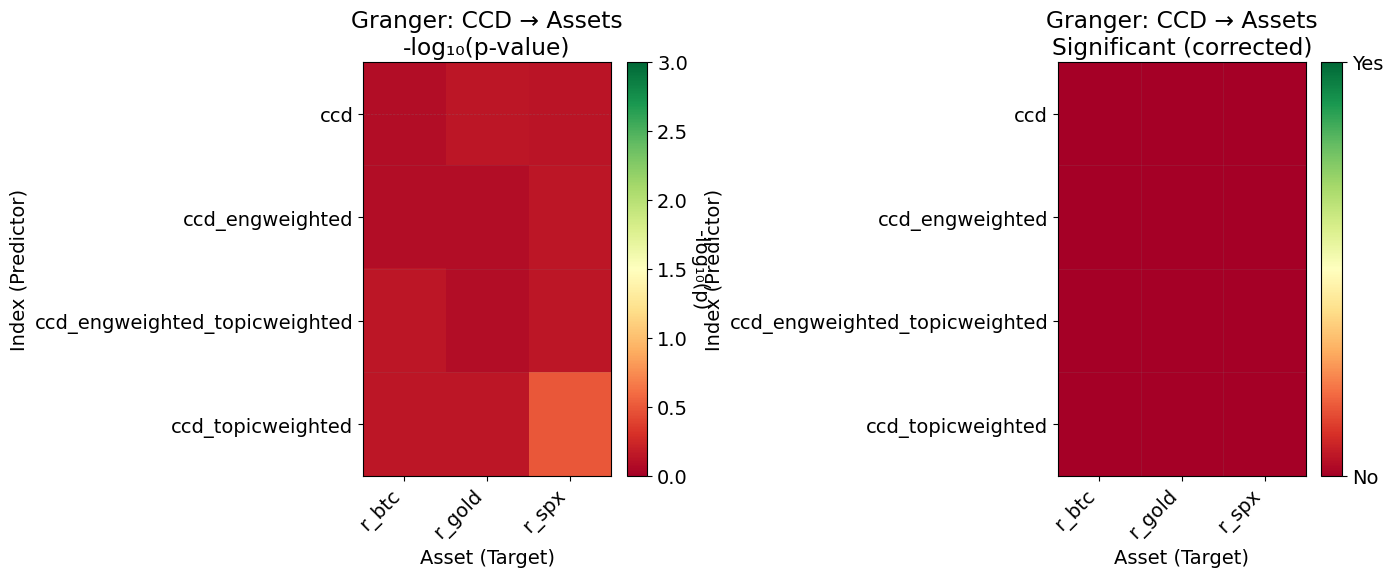

In [8]:
print("\n" + "="*70)
print("Granger Causality Tests")
print("="*70)

pval_mat, pval_corrected, sig_mat = granger_comparison_variants(
    df, ccd_variants, ASSET_COLS,
    maxlag=MAX_LAG, ic=IC, alpha=ALPHA, correction_method=CORRECTION_METHOD
)

In [9]:
# Variant performance summary
print("\n" + "="*70)
print("Performance Summary")
print("="*70)
performance = summarize_variant_performance(pval_mat, sig_mat, ccd_variants)


Performance Summary

VARIANT PERFORMANCE SUMMARY


,variant,n_significant,mean_pvalue,min_pvalue
0,ccd,0,0.546455,0.421323
1,ccd_engweighted,0,0.602709,0.377638
2,ccd_topicweighted,0,0.175339,0.026325
3,ccd_engweighted_topicweighted,0,0.491069,0.321812


In [10]:
# Save results
pval_mat.to_csv(os.path.join(OUTPUT_DIR, "ccd_granger_pvalues.csv"))
pval_corrected.to_csv(os.path.join(OUTPUT_DIR, "ccd_granger_pvalues_corrected.csv"))
sig_mat.to_csv(os.path.join(OUTPUT_DIR, "ccd_granger_significant.csv"))
performance.to_csv(os.path.join(OUTPUT_DIR, "ccd_variant_performance.csv"), index=False)

print("\n✓ Results saved to:", OUTPUT_DIR)


✓ Results saved to: ./data/fm_prelim/


## Stationarity Tests

Check if series are stationary (required for valid Granger tests)

In [11]:
print("\n" + "="*70)
print("Stationarity Tests (ADF & KPSS)")
print("="*70)

stationarity_results = []

for var in ccd_variants:
    if var in df.columns:
        adf = adf_test(df[var])
        kpss_result = kpss_test(df[var])
        
        stationarity_results.append({
            'index': var,
            'adf_stat': adf['statistic'],
            'adf_pval': adf['pvalue'],
            'adf_stationary': '✓' if adf['is_stationary'] else '✗',
            'kpss_stat': kpss_result['statistic'],
            'kpss_pval': kpss_result['pvalue'],
            'kpss_stationary': '✓' if kpss_result['is_stationary'] else '✗'
        })

stationarity_df = pd.DataFrame(stationarity_results)
display(stationarity_df)

print("\nInterpretation:")
print("  ADF: H0=non-stationary. ✓ if p<0.05 (reject H0, series is stationary)")
print("  KPSS: H0=stationary. ✓ if p>0.05 (fail to reject H0, series is stationary)")


Stationarity Tests (ADF & KPSS)


/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/finance/exploration/statistical_tests.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)
/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/finance/exploration/statistical_tests.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)
/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/finance/exploration/statistical_tests.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value ret

,index,adf_stat,adf_pval,adf_stationary,kpss_stat,kpss_pval,kpss_stationary
0,ccd,-10.598904,6.244761e-19,✓,0.151638,0.1,✓
1,ccd_engweighted,-10.681603,3.927391e-19,✓,0.153959,0.1,✓
2,ccd_topicweighted,-9.438699,4.961619e-16,✓,0.084101,0.1,✓
3,ccd_engweighted_topicweighted,-8.172522,8.546806e-13,✓,0.212296,0.1,✓



Interpretation:
  ADF: H0=non-stationary. ✓ if p<0.05 (reject H0, series is stationary)
  KPSS: H0=stationary. ✓ if p>0.05 (fail to reject H0, series is stationary)


## Bidirectional Granger Tests

Test causality in both directions for best performing variant

In [12]:
print("\n" + "="*70)
print("Bidirectional Granger Tests")
print("="*70)

# Use best performing variant
best_variant = performance.iloc[0]['variant']
print(f"\nBest variant: {best_variant}\n")

for asset in ASSET_COLS:
    print(f"\n{best_variant} ↔ {asset}:")
    print("-" * 70)
    result = bidirectional_granger_test(df, best_variant, asset, maxlag=MAX_LAG, ic=IC)
    display(result)


Bidirectional Granger Tests

Best variant: ccd


ccd ↔ r_btc:
----------------------------------------------------------------------


,direction,optimal_lag,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,ccd → r_btc,1,0.725961,0.012282,True,False
1,r_btc → ccd,2,0.481870,0.217097,False,False



ccd ↔ r_gold:
----------------------------------------------------------------------


,direction,optimal_lag,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,ccd → r_gold,1,0.421323,0.421323,False,False
1,r_gold → ccd,2,0.915424,0.648865,False,False



ccd ↔ r_spx:
----------------------------------------------------------------------


,direction,optimal_lag,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,ccd → r_spx,1,0.492082,0.115222,False,False
1,r_spx → ccd,2,0.085606,0.085606,False,False


## Event Window Analysis

How do CCD variants behave during major tariff events?

In [13]:
EVENT_WINDOWS = [
    ("Initial Tariff Announcements", "2025-01-20", "2025-01-26"),
    ("Tariffs Postponed", "2025-03-04", "2025-03-06"),
    ("China Retaliation & US Tariffs", "2025-03-10", "2025-03-13"),
    ("Global Tariffs", "2025-04-02", "2025-04-06"),
    ("US-China Tariff Threats", "2025-04-09", "2025-04-12"),
    ("Tariffs Relaxed", "2025-04-27", "2025-05-04"),
    ("Trade Deals", "2025-05-05", "2025-05-14"),
    ("Apple Tariff Threat", "2025-05-20", "2025-05-25"),
]

print("\n" + "="*70)
print("Event Window Analysis")
print("="*70)

event_comparison = event_window_comparison(df, ccd_variants, EVENT_WINDOWS, pre_days=7, post_days=7)

# Display delta rows only (more compact)
delta_rows = event_comparison[event_comparison['phase'].str.contains('Δ', na=False)]
display(delta_rows)

# Save
event_comparison.to_csv(os.path.join(OUTPUT_DIR, "ccd_event_windows.csv"), index=False)
print("\n✓ Event analysis saved")


Event Window Analysis


,event,phase,n,ccd_mean,ccd_std,ccd_engweighted_mean,ccd_engweighted_std,ccd_topicweighted_mean,ccd_topicweighted_std,ccd_engweighted_topicweighted_mean,ccd_engweighted_topicweighted_std
3,Initial Tariff Announcements,Δ during-pre,NaN,-0.086027,NaN,-0.073127,NaN,-0.060123,NaN,0.029067,NaN
4,Initial Tariff Announcements,Δ post-during,NaN,0.107160,NaN,0.088755,NaN,0.011735,NaN,-0.019022,NaN
8,Tariffs Postponed,Δ during-pre,NaN,-0.058629,NaN,-0.052134,NaN,-0.046050,NaN,0.052477,NaN
9,Tariffs Postponed,Δ post-during,NaN,-0.004456,NaN,-0.007152,NaN,-0.011594,NaN,-0.046600,NaN
13,China Retaliation & US Tariffs,Δ during-pre,NaN,-0.024098,NaN,-0.007854,NaN,0.011943,NaN,-0.070036,NaN
14,China Retaliation & US Tariffs,Δ post-during,NaN,0.098663,NaN,0.090497,NaN,-0.078136,NaN,0.102385,NaN
18,Global Tariffs,Δ during-pre,NaN,0.146474,NaN,0.135979,NaN,0.059601,NaN,-0.058813,NaN
19,Global Tariffs,Δ post-during,NaN,-0.060285,NaN,-0.054773,NaN,0.037580,NaN,0.057744,NaN
23,US-China Tariff Threats,Δ during-pre,NaN,0.073783,NaN,0.072011,NaN,0.082586,NaN,0.096273,NaN
24,US-China Tariff Threats,Δ post-during,NaN,-0.069132,NaN,-0.067011,NaN,-0.138757,NaN,-0.154416,NaN



✓ Event analysis saved


## Summary

Comprehensive comparison of CCD variants

In [14]:
print("\n" + "="*70)
print("CCD VARIANT COMPARISON - SUMMARY")
print("="*70)

print("\n1. VARIANTS TESTED:")
for i, var in enumerate(ccd_variants, 1):
    print(f"   {i}. {var}")

print("\n2. CORRELATION WITH ASSETS (mean absolute):")
for var in ccd_variants:
    if var in df.columns:
        mean_abs_corr = df[[var] + ASSET_COLS].corr().loc[var, ASSET_COLS].abs().mean()
        print(f"   {var:40s}: {mean_abs_corr:.4f}")

print("\n3. GRANGER CAUSALITY (significant relationships after FDR):")
for _, row in performance.iterrows():
    print(f"   {row['variant']:40s}: {int(row['n_significant'])} significant")

print("\n4. BEST PERFORMING VARIANT:")
print(f"   {best_variant}")
print(f"   - Significant Granger relationships: {int(performance.iloc[0]['n_significant'])}/{len(ASSET_COLS)}")
print(f"   - Mean p-value: {performance.iloc[0]['mean_pvalue']:.4f}")

print("\n5. KEY INSIGHTS:")
print(f"   - CCD captures information asymmetry between creators and community")
print(f"   - High divergence may signal informed vs uninformed trading")
print(f"   - Potentially useful for detecting sentiment manipulation")

print("\n" + "="*70)
print("✓ CCD ANALYSIS COMPLETE")
print("="*70)


CCD VARIANT COMPARISON - SUMMARY

1. VARIANTS TESTED:
   1. ccd
   2. ccd_engweighted
   3. ccd_topicweighted
   4. ccd_engweighted_topicweighted

2. CORRELATION WITH ASSETS (mean absolute):
   ccd                                     : 0.0581
   ccd_engweighted                         : 0.0699
   ccd_topicweighted                       : 0.0365
   ccd_engweighted_topicweighted           : 0.0804

3. GRANGER CAUSALITY (significant relationships after FDR):
   ccd                                     : 0 significant
   ccd_engweighted                         : 0 significant
   ccd_topicweighted                       : 0 significant
   ccd_engweighted_topicweighted           : 0 significant

4. BEST PERFORMING VARIANT:
   ccd
   - Significant Granger relationships: 0/3
   - Mean p-value: 0.5465

5. KEY INSIGHTS:
   - CCD captures information asymmetry between creators and community
   - High divergence may signal informed vs uninformed trading
   - Potentially useful for detecting sentime